<a href="https://colab.research.google.com/github/Losorioh/BootCamp_Practice/blob/Proyecto_ICC/Radiografia_Digital_SQL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
### Importacion de paquetes
import sqlite3
import pandas as pd
import csv
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
### realizar conexion a la base de datos
#con= sqlite3.connect('BD_ICC.sqlite3')
con= sqlite3.connect('/content/drive/MyDrive/Colab Notebooks/BD_ICC.sqlite3')


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# crear la consulta
## Estructura de tabla para la tabla ICC
query ="""
CREATE TABLE ICC (
  id INTEGER PRIMARY KEY AUTOINCREMENT,
  ciudad TEXT NOT NULL,
  fecha INTEGER,
  subpilar TEXT DEFAULT NULL,
  valor REAL DEFAULT NULL
)"""
cursor = con.execute(query)

In [ ]:
ICC = pd.read_csv('BD_ICC_SQLITE2.csv')
ICC

In [ ]:

query= """
Select  * from ICC
"""
datos = pd.read_sql_query(query,con)
datos.head(1000)


,id,ciudad,fecha,subpilar,valor
0,1,Arauca,2019,TIC-1-1,2.667119
1,2,Arauca,2019,TIC-1-2,0.265503
2,3,Arauca,2019,TIC-1-3,2.081354
3,4,Arauca,2019,TIC-1-4,5.388456
4,5,Arauca,2019,TIC-1,2.600608
...,...,...,...,...,...
995,996,Medellin AM,2020,TIC-2-1,3.580450
996,997,Medellin AM,2020,TIC-2-2,3.577465
997,998,Medellin AM,2020,TIC-2-3,7.068487
998,999,Medellin AM,2020,TIC-2,4.742134


In [ ]:
cursor = con.execute("""
Select  ciudad  from ICC
Group by ciudad

""")
cursor.fetchall()

In [ ]:
ICC.to_sql('ICC', con, if_exists='append', index = False)

In [ ]:
# crear la consulta
## Estructura de tabla para la tabla ICC
query ="""
CREATE TABLE PILAR (
  ID_PILAR INTEGER PRIMARY KEY AUTOINCREMENT,
  PILAR TEXT NOT NULL,
  DES_PILAR TEXT NOT NULL
)"""
cursor = con.execute(query)

In [ ]:
PILAR = pd.read_csv('/content/Pilares.csv')
PILAR

,ID_PILAR,PILAR,DES_PILAR
0,1,TIC-1,Infraestructura TIC
1,2,TIC-1-1,Penetracion de internet banda ancha fijo
2,3,TIC-1-2,Ancho de banda de internet
3,4,TIC-1-3,Hogares con computador portatil o tablet
4,5,TIC-1-4,Uso de Internet
5,6,TIC-2,Capacidades TIC
6,7,TIC-2-1,Matriculados en programas TIC
7,8,TIC-2-2,Graduados en programas TIC
8,9,TIC-2-3,Programas TIC
9,10,INN-1,Investigacion


In [ ]:
PILAR.to_sql('PILAR', con, if_exists='append', index = False)

20

In [ ]:
query= """
Select  * from PILAR
"""
datos = pd.read_sql_query(query,con)
datos.head(1000)


,ID_PILAR,PILAR,DES_PILAR
0,1,TIC-1,Infraestructura TIC
1,2,TIC-1-1,Penetracion de internet banda ancha fijo
2,3,TIC-1-2,Ancho de banda de internet
3,4,TIC-1-3,Hogares con computador portatil o tablet
4,5,TIC-1-4,Uso de Internet
5,6,TIC-2,Capacidades TIC
6,7,TIC-2-1,Matriculados en programas TIC
7,8,TIC-2-2,Graduados en programas TIC
8,9,TIC-2-3,Programas TIC
9,10,INN-1,Investigacion


In [ ]:
cursor = con.execute("""
Select
id, Ciudad, fecha,
  subpilar, DES_PILAR,  valor
 from ICC
 JOIN PILAR ON subpilar = PILAR
 WHERE subpilar LIKE "TIC%"

""")
cursor.fetchall()

[(1,
  'Arauca',
  2019,
  'TIC-1-1',
  'Penetracion de internet banda ancha fijo',
  2.667119104),
 (2, 'Arauca', 2019, 'TIC-1-2', 'Ancho de banda de internet', 0.26550274),
 (3,
  'Arauca',
  2019,
  'TIC-1-3',
  'Hogares con computador portatil o tablet',
  2.081354006),
 (4, 'Arauca', 2019, 'TIC-1-4', 'Uso de Internet', 5.388455819),
 (5, 'Arauca', 2019, 'TIC-1', 'Infraestructura TIC', 2.600607917),
 (6, 'Arauca', 2019, 'TIC-2-1', 'Matriculados en programas TIC', 0.517580345),
 (7, 'Arauca', 2019, 'TIC-2-2', 'Graduados en programas TIC', 1.116271438),
 (8, 'Arauca', 2019, 'TIC-2-3', 'Programas TIC', 1.477279442),
 (9, 'Arauca', 2019, 'TIC-2', 'Capacidades TIC', 1.037043742),
 (23,
  'Armenia',
  2019,
  'TIC-1-1',
  'Penetracion de internet banda ancha fijo',
  8.303359348),
 (24, 'Armenia', 2019, 'TIC-1-2', 'Ancho de banda de internet', 0.453311184),
 (25,
  'Armenia',
  2019,
  'TIC-1-3',
  'Hogares con computador portatil o tablet',
  5.578772091),
 (26, 'Armenia', 2019, 'TIC-1-

In [ ]:
# crear la consulta
## Estructura de tabla para la tabla Proyeccion Dane Población
query ="""
CREATE TABLE DANE_POBLACION (
  IDDPM INTEGER PRIMARY KEY AUTOINCREMENT,
  DP TEXT NOT NULL,
  DPNOM TEXT NOT NULL,
  CODMPIO TEXT NOT NULL,
  DPMP  TEXT NOT NULL,
  FECHA INTEGER,
  POBLACION REAL DEFAULT NULL
 )"""
cursor = con.execute(query)



In [ ]:
#query ="""
#DROP TABLE MUN_REGION
#"""
#cursor = con.execute(query)

In [ ]:
DANE_POBLACION = pd.read_csv('/content/Proyeccion Dane Poblacion.csv')
DANE_POBLACION

,IDDPM,DP,DPNOM,CODMPIO,DPMP,FECHA,POBLACION
0,1,5,Antioquia,5001,Medellin AM,2020,2519592
1,2,5,Antioquia,5001,Medellin AM,2021,2549008
2,3,5,Antioquia,5001,Medellin AM,2022,2572350
3,4,5,Antioquia,5001,Medellin AM,2023,2595300
4,5,5,Antioquia,5001,Medellin AM,2024,2616335
...,...,...,...,...,...,...,...
507,508,99,Vichada,99001,Puerto Carreno,2031,24643
508,509,99,Vichada,99001,Puerto Carreno,2032,24912
509,510,99,Vichada,99001,Puerto Carreno,2033,25172
510,511,99,Vichada,99001,Puerto Carreno,2034,25422


In [ ]:
DANE_POBLACION.to_sql('DANE_POBLACION', con, if_exists='append', index = False)

512

In [ ]:
query= """
Select  * from DANE_POBLACION
"""
datos = pd.read_sql_query(query,con)
datos.head(1000)


,IDDPM,DP,DPNOM,CODMPIO,DPMP,FECHA,POBLACION
0,1,5,Antioquia,5001,Medellin AM,2020,2519592.0
1,2,5,Antioquia,5001,Medellin AM,2021,2549008.0
2,3,5,Antioquia,5001,Medellin AM,2022,2572350.0
3,4,5,Antioquia,5001,Medellin AM,2023,2595300.0
4,5,5,Antioquia,5001,Medellin AM,2024,2616335.0
...,...,...,...,...,...,...,...
507,508,99,Vichada,99001,Puerto Carreno,2031,24643.0
508,509,99,Vichada,99001,Puerto Carreno,2032,24912.0
509,510,99,Vichada,99001,Puerto Carreno,2033,25172.0
510,511,99,Vichada,99001,Puerto Carreno,2034,25422.0


In [ ]:
#cursor = con.execute("""
#delete from   DANE_POBLACION
#where IDDPM =309
#""")
#cursor.fetchall()

[]

In [ ]:
# crear la consulta
## Estructura de tabla para la tabla Proyeccion Dane Población
query ="""
CREATE TABLE MUN_REGION (
  IDMR INTEGER PRIMARY KEY AUTOINCREMENT,
  CIUDADES TEXT NOT NULL,
  FECHA INTEGER,
  CATEGORIA_NUMB INTEGER,
  CATEGORIA_POBLACION TEXT NOT NULL,
  REGION TEXT NOT NULL
 )"""
cursor = con.execute(query)

In [ ]:
MUN_REGION = pd.read_csv('/content/Mun_Region.csv')
MUN_REGION

,IDMR,CIUDADES,FECHA,CATEGORIA_NUMB,CATEGORIA_POBLACION,REGION
0,1,Bogota D.C.,2019,0,Superior o igual a 500.001,Andina
1,2,Medellin AM,2019,0,Superior o igual a 500.001,Andina
2,3,Cali AM,2019,0,Superior o igual a 500.001,Pacifica
3,4,Bucaramanga AM,2019,0,Superior o igual a 500.001,Andina
4,5,Barranquilla AM,2019,0,Superior o igual a 500.001,Caribe
...,...,...,...,...,...,...
187,188,Quibdo,2024,4,Entre 20.001 y 30.000,Pacifica
188,189,Mocoa,2024,5,Entre 10.001 y 20.000,Amazonia
189,190,Leticia,2024,5,Entre 10.001 y 20.000,Amazonia
190,191,San Andres,2024,5,Entre 10.001 y 20.000,Caribe


In [ ]:
query= """
Select  * from MUN_REGION
"""
datos = pd.read_sql_query(query,con)
datos.head(1000)

,IDMR,CIUDADES,FECHA,CATEGORIA_NUMB,CATEGORIA_POBLACION,REGION
0,1,Bogota D.C.,2019,0,Superior o igual a 500.001,Andina
1,2,Medellin AM,2019,0,Superior o igual a 500.001,Andina
2,3,Cali AM,2019,0,Superior o igual a 500.001,Pacifica
3,4,Bucaramanga AM,2019,0,Superior o igual a 500.001,Andina
4,5,Barranquilla AM,2019,0,Superior o igual a 500.001,Caribe
...,...,...,...,...,...,...
187,188,Quibdo,2024,4,Entre 20.001 y 30.000,Pacifica
188,189,Mocoa,2024,5,Entre 10.001 y 20.000,Amazonia
189,190,Leticia,2024,5,Entre 10.001 y 20.000,Amazonia
190,191,San Andres,2024,5,Entre 10.001 y 20.000,Caribe


In [ ]:
MUN_REGION.to_sql('MUN_REGION', con, if_exists='append', index = False)

192

In [ ]:
cursor = con.execute("""
SELECT * FROM sqlite_master
""")
cursor.fetchall()

[('table',
  'ICC',
  'ICC',
  2,
  'CREATE TABLE ICC (\n  id INTEGER PRIMARY KEY AUTOINCREMENT,\n  ciudad TEXT NOT NULL,\n  fecha INTEGER,\n  subpilar TEXT DEFAULT NULL,\n  valor REAL DEFAULT NULL\n)'),
 ('table',
  'sqlite_sequence',
  'sqlite_sequence',
  3,
  'CREATE TABLE sqlite_sequence(name,seq)'),
 ('table',
  'PILAR',
  'PILAR',
  41,
  'CREATE TABLE PILAR (\n  ID_PILAR INTEGER PRIMARY KEY AUTOINCREMENT,\n  PILAR TEXT NOT NULL,\n  DES_PILAR TEXT NOT NULL\n)'),
 ('table',
  'DANE_POBLACION',
  'DANE_POBLACION',
  42,
  'CREATE TABLE DANE_POBLACION (\n  IDDPM INTEGER PRIMARY KEY AUTOINCREMENT,\n  DP TEXT NOT NULL,\n  DPNOM TEXT NOT NULL,\n  CODMPIO TEXT NOT NULL,\n  DPMP  TEXT NOT NULL,\n  FECHA INTEGER,\n  POBLACION REAL DEFAULT NULL\n )'),
 ('table',
  'MUN_REGION',
  'MUN_REGION',
  49,
  'CREATE TABLE MUN_REGION (\n  IDMR INTEGER PRIMARY KEY AUTOINCREMENT,\n  CIUDADES TEXT NOT NULL,\n  FECHA INTEGER,\n  CATEGORIA_NUMB INTEGER,\n  CATEGORIA_POBLACION TEXT NOT NULL,\n  REGION 

In [ ]:
cursor = con.execute("""
SELECT * FROM  MUN_REGION
where CIUDADES ='San Andres'
""")
cursor.fetchall()

[(31, 'San Andres', 2019, 5, 'Entre 10.001 y 20.000', 'Caribe'),
 (63, 'San Andres', 2020, 5, 'Entre 10.001 y 20.000', 'Caribe'),
 (95, 'San Andres', 2021, 5, 'Entre 10.001 y 20.000', 'Caribe'),
 (127, 'San Andres', 2022, 5, 'Entre 10.001 y 20.000', 'Caribe'),
 (159, 'San Andres', 2023, 5, 'Entre 10.001 y 20.000', 'Caribe'),
 (191, 'San Andres', 2024, 5, 'Entre 10.001 y 20.000', 'Caribe')]

In [ ]:
query= """
SELECT I.Ciudad, I.fecha, I.subpilar, I.valor, D.Poblacion

FROM  ICC as I
join DANE_POBLACION as D on (I.Ciudad = D.DPMP and I.Fecha=D.Fecha)
where I.fecha = 2024 and subpilar='INN'
"""
datos = pd.read_sql_query(query,con)
datos.head(1000)

,ciudad,fecha,subpilar,valor,POBLACION
0,Arauca,2024,INN,0.375252,100690.0
1,Armenia,2024,INN,4.591509,309474.0
2,Barranquilla AM,2024,INN,3.441734,1334509.0
3,Bucaramanga AM,2024,INN,4.018158,619703.0
4,Cali AM,2024,INN,4.041954,2283846.0
5,Cucuta AM,2024,INN,1.780746,812176.0
6,Florencia,2024,INN,1.088401,5509.0
7,Florencia,2024,INN,1.088401,179233.0
8,Ibague,2024,INN,3.526422,544132.0
9,Inirida,2024,INN,1.261512,37917.0


In [ ]:
query="""
SELECT I.Ciudad, I.fecha, I.subpilar, I.valor, D.Poblacion,  CATEGORIA_NUMB, M.CATEGORIA_POBLACION, M.REGION

FROM  ICC as I
left join MUN_REGION as M on (I.Ciudad = M.CIUDADES and I.Fecha=M.Fecha)
left join DANE_POBLACION as D on (I.Ciudad = D.DPMP and I.Fecha=D.Fecha)
where I.fecha > 2019 and subpilar in ('TIC', 'INN')
order by I.ciudad, I.subpilar
""";
datos = pd.read_sql_query(query,con)
datos.head(1000)


,ciudad,fecha,subpilar,valor,POBLACION,CATEGORIA_NUMB,CATEGORIA_POBLACION,REGION
0,Arauca,2020,INN,0.072885,93457.0,4,Entre 20.001 y 30.000,Orinoquia
1,Arauca,2021,INN,0.078023,95631.0,4,Entre 20.001 y 30.000,Orinoquia
2,Arauca,2022,INN,0.107678,97771.0,4,Entre 20.001 y 30.000,Orinoquia
3,Arauca,2023,INN,0.129681,99393.0,4,Entre 20.001 y 30.000,Orinoquia
4,Arauca,2024,INN,0.375252,100690.0,4,Entre 20.001 y 30.000,Orinoquia
...,...,...,...,...,...,...,...,...
335,Yopal,2020,TIC,3.422229,180151.0,1,Entre 100.001 y 500.000,Orinoquia
336,Yopal,2021,TIC,3.812484,184803.0,1,Entre 100.001 y 500.000,Orinoquia
337,Yopal,2022,TIC,3.760003,187954.0,1,Entre 100.001 y 500.000,Orinoquia
338,Yopal,2023,TIC,4.048363,191133.0,1,Entre 100.001 y 500.000,Orinoquia


5 ciudades principales subpilar TIC

In [ ]:
query="""
SELECT I.Ciudad, I.fecha, I.subpilar, DES_PILAR, I.valor

FROM  ICC as I
JOIN PILAR ON subpilar = PILAR

where I.Ciudad in ('Tunja','Bogota D.C.', 'Medellin AM', 'Manizales AM', 'Pereira AM', 'Bucaramanga AM')
and (subpilar Like 'TIC-1-%' or subpilar Like 'TIC-2-%')
order by I.fecha, I.subpilar, I.valor desc
""";
datos = pd.read_sql_query(query,con)
datos.head(1000)

In [ ]:
query="""
SELECT I.Ciudad, I.fecha, I.subpilar, DES_PILAR, I.valor

FROM  ICC as I
JOIN PILAR ON subpilar = PILAR

where I.Ciudad in ('Tunja','Bogota D.C.', 'Medellin AM', 'Manizales AM', 'Pereira AM', 'Bucaramanga AM')
and subpilar in ('TIC-1', 'TIC-2')
order by I.fecha, I.subpilar, I.valor desc
""";
datos = pd.read_sql_query(query,con)
datos.head(1000)

,ciudad,fecha,subpilar,DES_PILAR,valor
0,Bogota D.C.,2019,TIC-1,Infraestructura TIC,7.069155
1,Pereira AM,2019,TIC-1,Infraestructura TIC,6.010799
2,Medellin AM,2019,TIC-1,Infraestructura TIC,5.803930
3,Bucaramanga AM,2019,TIC-1,Infraestructura TIC,5.686495
4,Tunja,2019,TIC-1,Infraestructura TIC,5.569409
...,...,...,...,...,...
67,Tunja,2024,TIC-2,Capacidades TIC,8.264152
68,Manizales AM,2024,TIC-2,Capacidades TIC,5.840703
69,Medellin AM,2024,TIC-2,Capacidades TIC,5.265660
70,Pereira AM,2024,TIC-2,Capacidades TIC,5.249703


In [ ]:
query="""
SELECT I.Ciudad, I.fecha, I.subpilar, DES_PILAR, I.valor

FROM  ICC as I
JOIN PILAR ON subpilar = PILAR

where I.Ciudad in ('Tunja','Bogota D.C.', 'Medellin AM', 'Manizales AM', 'Pereira AM', 'Bucaramanga AM', 'Armenia', 'Cali AM')
and subpilar in ('INN-1', 'INN-2')
order by I.fecha, I.subpilar, I.valor desc
""";
datos = pd.read_sql_query(query,con)
datos.head(1000)

,ciudad,fecha,subpilar,DES_PILAR,valor
0,Tunja,2019,INN-1,Investigacion,6.593401
1,Manizales AM,2019,INN-1,Investigacion,5.650098
2,Bogota D.C.,2019,INN-1,Investigacion,5.372347
3,Medellin AM,2019,INN-1,Investigacion,4.368591
4,Bucaramanga AM,2019,INN-1,Investigacion,3.977046
...,...,...,...,...,...
91,Manizales AM,2024,INN-2,Registros de propiedad industrial,4.137236
92,Cali AM,2024,INN-2,Registros de propiedad industrial,3.975780
93,Bucaramanga AM,2024,INN-2,Registros de propiedad industrial,3.941218
94,Pereira AM,2024,INN-2,Registros de propiedad industrial,3.865379


In [ ]:

import matplotlib.pyplot as plt
import seaborn as sns
# Crear el DataFrame con los valores totales de los pilares Adopción TIC y Innovación
df_ICC_TIC_INN = datos

# Crear un objeto FacetGrid para dividir los gráficos por año
g = sns.FacetGrid(df_ICC_TIC_INN, col='fecha', col_wrap=2, height=5)  # Dividir en 3 columnas por fila

# Gráfico de barras para TIC_Total en cada subgráfico
g.map(sns.barplot, 'ciudad', 'subpilar'=='TIC-1', color='skyblue')

# Gráfico de líneas para INN_Total en cada subgráfico
g.map(sns.lineplot, 'ciudad', 'subpilar'=='INN-1', color='red', marker='o')

# Ajustar las etiquetas de los ejes y el título
g.set_axis_labels('ciudad', 'valor')  # Etiquetas de los ejes
g.set_titles('Año: {col_name}')  # Título para cada subgráfico (Año)

# Ajustar la rotación de las etiquetas de las ciudades para evitar solapamiento
for ax in g.axes.flat:
    for label in ax.get_xticklabels():
        label.set_rotation(90)

# Ajustar la leyenda
g.add_legend()

# Mostrar el gráfico
plt.tight_layout()
plt.show()



In [ ]:

# Crear el DataFrame con los valores totales de los pilares Adopción TIC y Innovación
df_ICC_TIC_INN = datos
# Filter data for TIC-1 and INN-1
tic1_data = df_ICC_TIC_INN[df_ICC_TIC_INN['subpilar'] == 'TIC-1']
tic2_data = df_ICC_TIC_INN[df_ICC_TIC_INN['subpilar'] == 'TIC-2']

df_merged = pd.merge(tic1_data, tic1_data, on=["ciudad", "fecha"], how='left', suffixes=('_TIC1', '_TIC2'))

# Create a FacetGrid
g = sns.FacetGrid(df_merged, col='fecha', col_wrap=2, height=5)

# Bar plot for TIC-1
g.map(sns.barplot, 'ciudad', 'valor_TIC1',  color='skyblue', label='TIC')

# Line plot for INN-1
g.map(sns.lineplot, 'ciudad', 'valor_TIC2', color='red', marker='o', label='INN')

# Set labels and titles
g.set_axis_labels('Ciudad', 'Valor')
g.set_titles('Año: {col_name}')

# Rotate x-axis labels
for ax in g.axes.flat:
    for label in ax.get_xticklabels():
        label.set_rotation(90)

# Add legend
g.add_legend()

# Show plot
plt.tight_layout()
plt.show()

In [ ]:
df_ICC_TIC_INN = datos
# Filter data for TIC-1 and INN-1
tic1_data = df_ICC_TIC_INN[df_ICC_TIC_INN['subpilar'] == 'TIC-1']
tic2_data = df_ICC_TIC_INN[df_ICC_TIC_INN['subpilar'] == 'TIC-2']

df_merged = pd.merge(tic1_data, tic1_data, on=["ciudad", "fecha"], how='left', suffixes=('_TIC1', '_TIC2'))
df_merged


,ciudad,fecha,subpilar_TIC1,DES_PILAR_TIC1,valor_TIC1,subpilar_TIC2,DES_PILAR_TIC2,valor_TIC2
0,Bogota D.C.,2019,TIC-1,Infraestructura TIC,7.069155,TIC-1,Infraestructura TIC,7.069155
1,Pereira AM,2019,TIC-1,Infraestructura TIC,6.010799,TIC-1,Infraestructura TIC,6.010799
2,Medellin AM,2019,TIC-1,Infraestructura TIC,5.803930,TIC-1,Infraestructura TIC,5.803930
3,Bucaramanga AM,2019,TIC-1,Infraestructura TIC,5.686495,TIC-1,Infraestructura TIC,5.686495
4,Tunja,2019,TIC-1,Infraestructura TIC,5.569409,TIC-1,Infraestructura TIC,5.569409
5,Manizales AM,2019,TIC-1,Infraestructura TIC,5.289743,TIC-1,Infraestructura TIC,5.289743
6,Bogota D.C.,2020,TIC-1,Infraestructura TIC,7.264756,TIC-1,Infraestructura TIC,7.264756
7,Pereira AM,2020,TIC-1,Infraestructura TIC,6.177789,TIC-1,Infraestructura TIC,6.177789
8,Medellin AM,2020,TIC-1,Infraestructura TIC,5.953178,TIC-1,Infraestructura TIC,5.953178
9,Bucaramanga AM,2020,TIC-1,Infraestructura TIC,5.837080,TIC-1,Infraestructura TIC,5.837080


In [ ]:
# promedios por año Sub Pilar
query="""
SELECT  fecha, subpilar, Avg(I.valor)

FROM  ICC as I
where  subpilar in ('TIC', 'INN')
Group by fecha, I.subpilar
""";
datos = pd.read_sql_query(query,con)
datos.head(1000)

,fecha,subpilar,Avg(I.valor)
0,2019,INN,1.909501
1,2019,TIC,3.694097
2,2020,INN,2.205339
3,2020,TIC,3.699323
4,2021,INN,2.173892
5,2021,TIC,3.783263
6,2022,INN,2.339788
7,2022,TIC,4.051977
8,2023,INN,2.357024
9,2023,TIC,4.286590


from matplotlib import pyplot as plt
_df_2['fecha'].plot(kind='hist', bins=20, title='fecha')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_3['Avg(I.valor)'].plot(kind='hist', bins=20, title='Avg(I.valor)')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
import seaborn as sns
_df_4.groupby('subpilar').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_5.plot(kind='scatter', x='fecha', y='Avg(I.valor)', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

...

from matplotlib import pyplot as plt
_df_9['Avg(I.valor)'].plot(kind='line', figsize=(8, 4), title='Avg(I.valor)')
plt.gca().spines[['top', 'right']].set_visible(False)

<string>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_10['subpilar'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_10, x='fecha', y='subpilar', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

<string>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_11['subpilar'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_11, x='Avg(I.valor)', y='subpilar', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

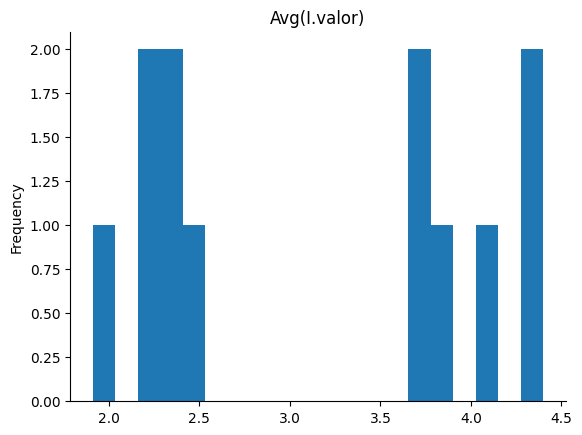

In [ ]:
from matplotlib import pyplot as plt
_df_3['Avg(I.valor)'].plot(kind='hist', bins=20, title='Avg(I.valor)')
plt.gca().spines[['top', 'right',]].set_visible(False)